<a href="https://colab.research.google.com/github/softwareJengineer/DSC-445-hw/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Jennifer Schwabe
### 2241210
### DSC 445
### HW 2
### *I have completed this work independently. The solutions given are entirely my own work.*

# Problem 1

## a.
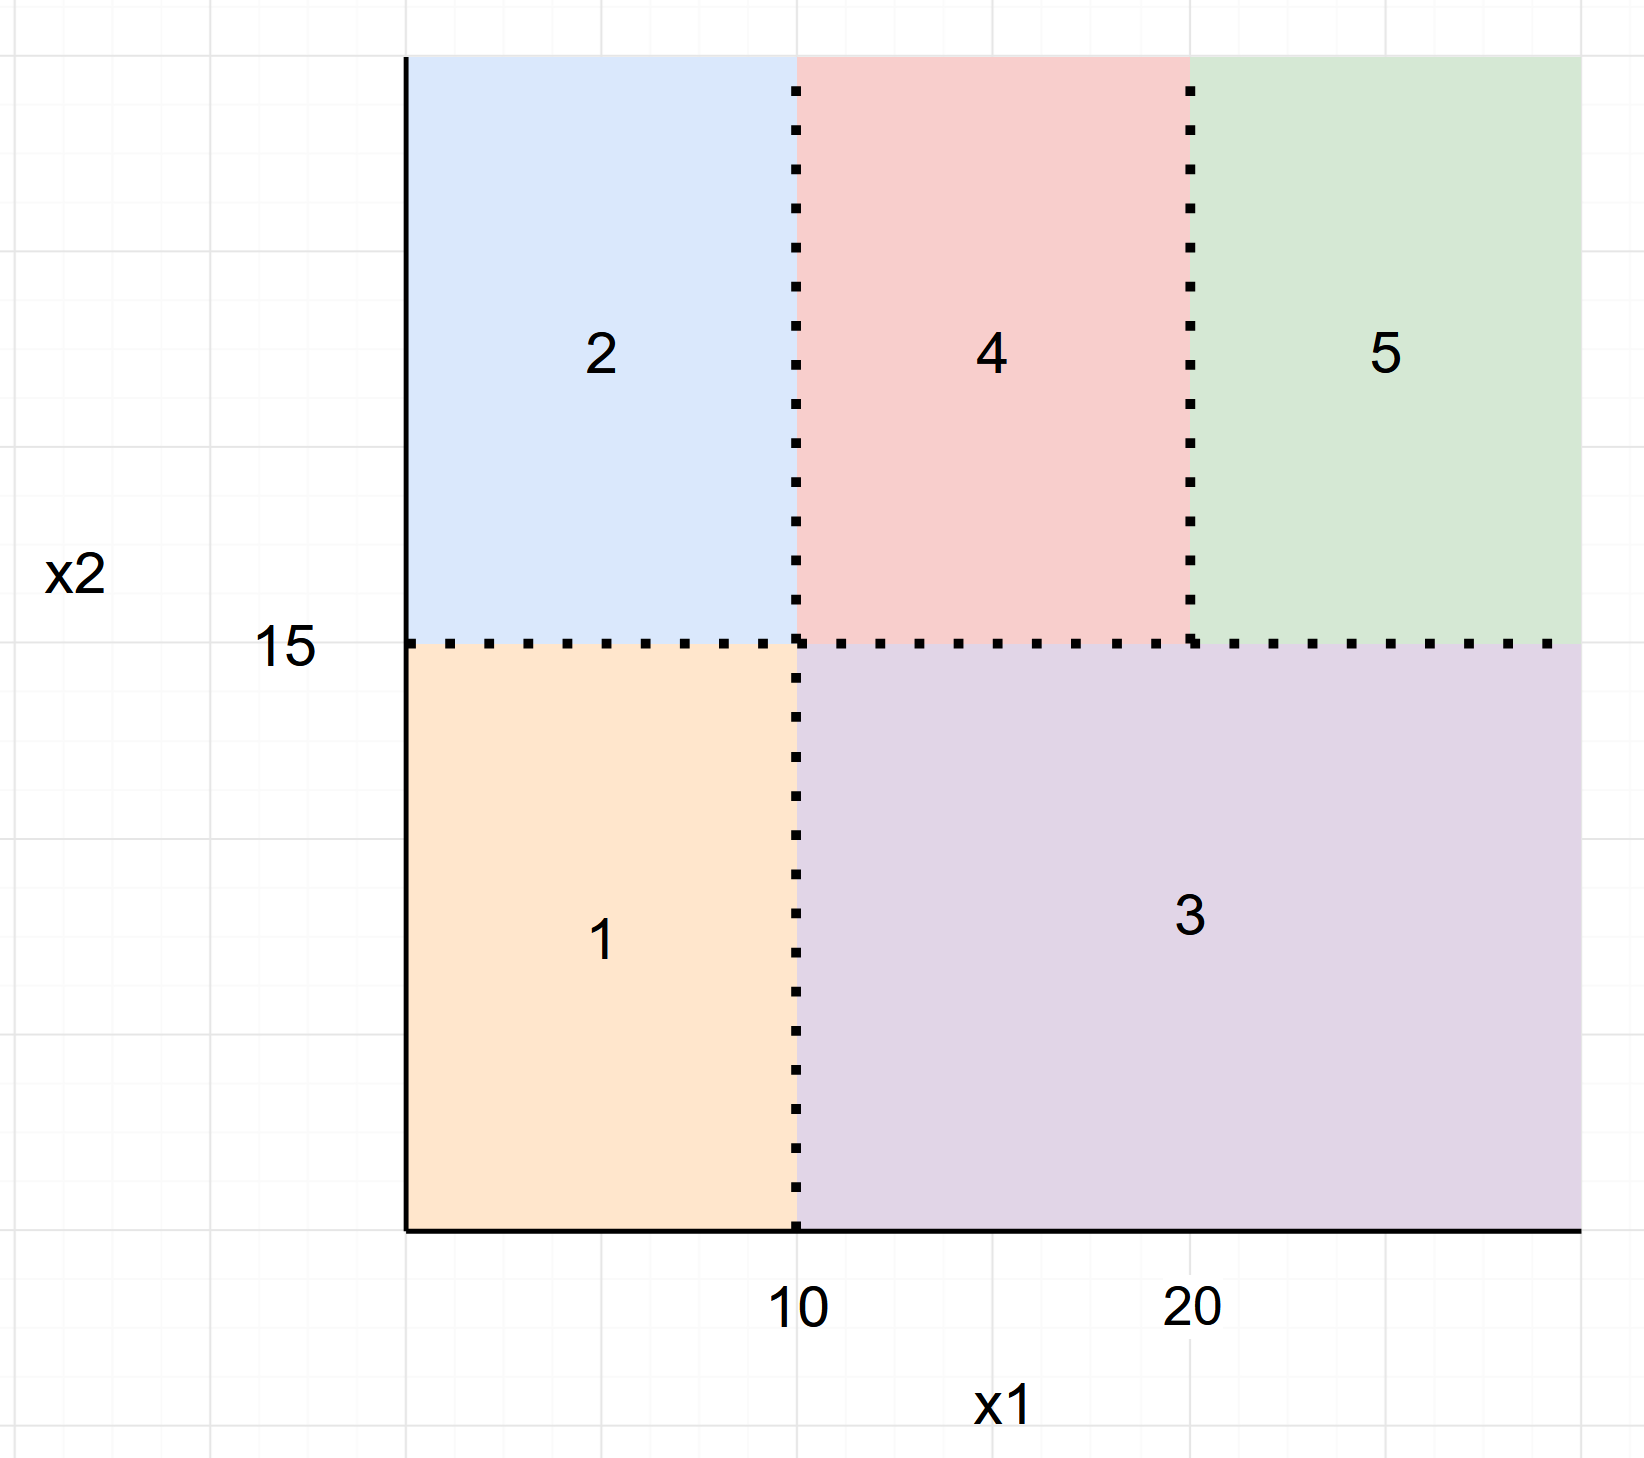

## b.
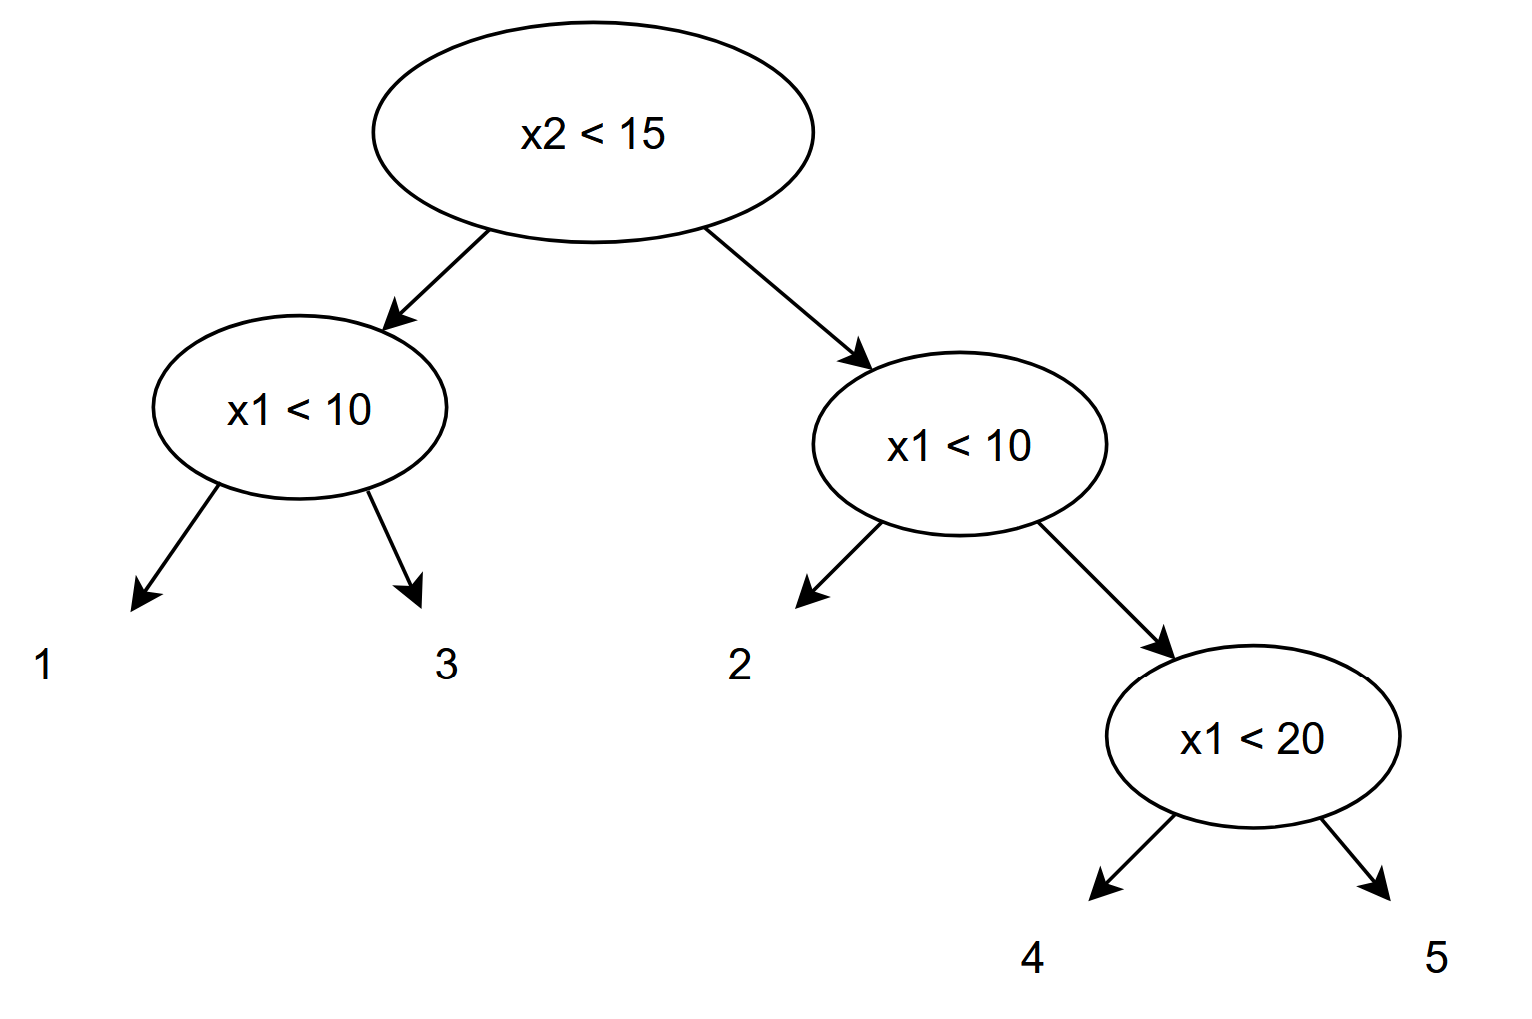

## c.

According to the diagram before partitioning, there are 3 points in class 1, 1 point in class 2, 3 points in class 3, 3 points in class 4, and 1 point in class 5, for 11 points overall.

Gini index before classification:

$G_{all}=\frac{3}{11}(1-\frac{3}{11})+\frac{1}{11}(1-\frac{1}{11})+\frac{3}{11}(1-\frac{3}{11})+\frac{3}{11}(1-\frac{3}{11})+\frac{1}{11}(1-\frac{1}{11})=0.893$

After partitioning, we have 5 sections, as shown below:

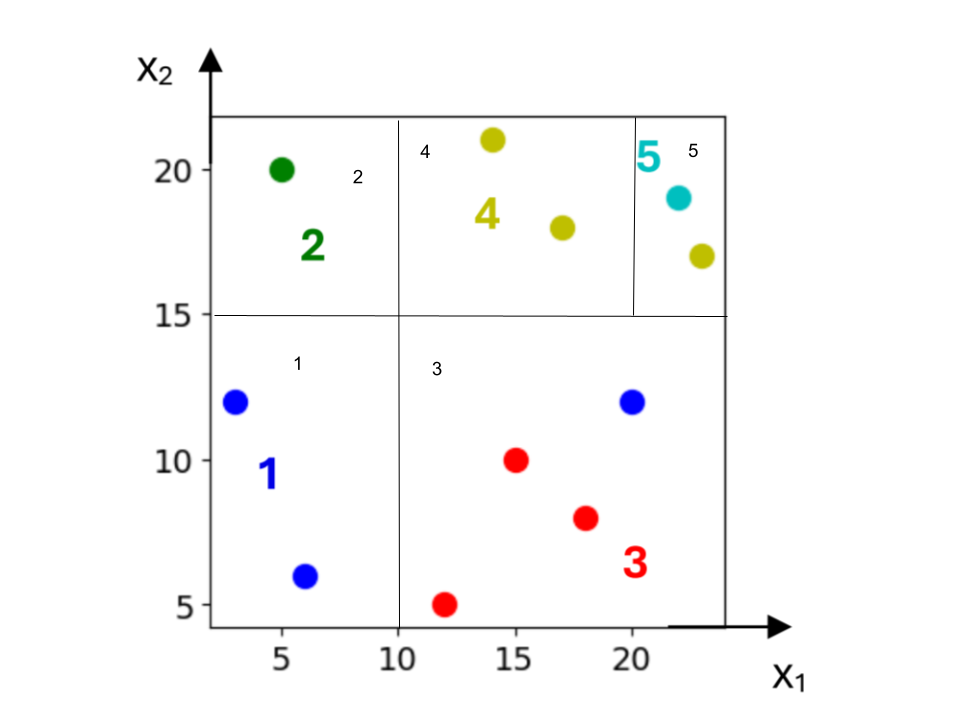

Section 1 has 2 points in class 1. Section 2 has 1 point in class 2. Section 3 has 3 points in class 3 and 1 point in class 2. Section 4 has 2 points in class 4. Section 5 has 1 point in class 4 and 1 point in class 5. The Gini index for each section is shown below:

$Gini_{1}=\frac{2}{2}(1-\frac{2}{2})=0$

$Gini_{2}=\frac{1}{1}(1-\frac{1}{1})=0$

$Gini_{3}=\frac{3}{4}(1-\frac{3}{4})+\frac{1}{4}(1-\frac{1}{4})=0.375$

$Gini_{4}=\frac{2}{2}(1-\frac{2}{2})=0$

$Gini_{5}=\frac{1}{2}(1-\frac{1}{2})+\frac{1}{2}(1-\frac{1}{2})=0.5$

So the overall Gini for classifier 1 would be:

$Gini_{classifier}=\frac{0+0+0.375+0+0.5}{5}=0.175$

# Problem 2


In [1]:
from tensorflow import keras
import pandas as pd
import numpy as np

dat=pd.read_csv("obesity_prediction.csv")
X = dat.iloc[:,:-1].to_numpy()
y = dat.iloc[:,-1].to_numpy()

## a.

In [2]:
from sklearn.preprocessing import OneHotEncoder
X_cat = X[:,8:]
X_num = X[:,:8]
X_cat = OneHotEncoder(sparse_output=False).fit_transform(X_cat)
X = np.concatenate((X_num, X_cat), axis=1)
X = np.float32(X)
C = np.unique(y)
print(X.shape)
print(C)
print(X[0:3])

(2111, 31)
['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']
[[21.    1.62 64.    2.    3.    2.    0.    1.    1.    0.    0.    1.
   1.    0.    0.    0.    1.    0.    1.    0.    1.    0.    0.    0.
   0.    1.    0.    0.    0.    1.    0.  ]
 [21.    1.52 56.    3.    3.    3.    3.    0.    1.    0.    0.    1.
   1.    0.    0.    0.    1.    0.    0.    1.    0.    1.    0.    0.
   1.    0.    0.    0.    0.    1.    0.  ]
 [23.    1.8  77.    2.    3.    2.    2.    1.    0.    1.    0.    1.
   1.    0.    0.    0.    1.    0.    1.    0.    1.    0.    0.    1.
   0.    0.    0.    0.    0.    1.    0.  ]]


The new X has 2111 rows and 54 columns. There are 7 unique class labels.

## b.

In [3]:
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(y)
print(np.unique(y))

[0 1 2 3 4 5 6]


np.unique on the new y gives an array of values from 0 to 6. This is expected, as there were 7 unique class labels originally.

## c.


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import set_random_seed
randstate = 12
set_random_seed(randstate)
model = Sequential()
model.add(Dense(len(C),activation='softmax'))

We needed "softmax" activation for this layer because there were multiple output classes possible for the model. This means that there will be multiple neurons in the output layer, and softmax activation will transform the model's output into a list of probabilities for each target class. Then, we can use this list of probabilities to select the most likely class that a test point belongs to.

## d.


In [10]:
from sklearn.model_selection import train_test_split

model.compile(loss='sparse_categorical_crossentropy',optimizer='SGD',metrics=['accuracy'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=randstate)
print(X_train.shape, X_test.shape)

(1477, 31) (634, 31)


The training data has 1,477 points and the test data has 634 points. Both sets have 31 features.

## e.


In [12]:
model.fit(X_train, y_train, batch_size=5, epochs=100)
print(model.summary())
eval = model.evaluate(X_test, y_test)
print(eval)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4834 - loss: 10.5829
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4604 - loss: 11.1856
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4672 - loss: 11.3277
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4746 - loss: 11.4522
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4976 - loss: 10.1644
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4800 - loss: 10.4552
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4949 - loss: 10.3695
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4719 - loss: 10.6415
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5030 - loss: 9.7264
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4915 - loss: 10.6045
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4949 - loss: 10.5730
Epoch 12/100
296/296 ━━━━━━━━━━

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226 (908.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4858 - loss: 16.4216  
[16.4216251373291, 0.48580440878868103]


Based on the output values for each epoch, the first epoch had an accuracy of 0.1733 and a loss of 32.79. The final epoch had an acuracy of 0.55 and a loss of 8.70. model.summary() gave 224 trainable params. Running model.evaluate gave an accuracy of 0.49 and a loss of 16.42.

## f.


In [13]:
set_random_seed(randstate)

model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=5, epochs=100)
model.evaluate(X_test, y_test)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6039 - loss: 7.3282 
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7373 - loss: 1.8643
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7400 - loss: 1.7275
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7407 - loss: 1.6926
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7448 - loss: 1.6659
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7468 - loss: 1.6446
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7461 - loss: 1.6256
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7448 - loss: 1.6079
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7454 - loss: 1.5910
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7434 - loss: 1.5748
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7420 - loss: 1.5593
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━

[1.3314682245254517, 0.7350157499313354]

Using Adam as the optimizer, the first epoch had an accuracy of 0.60 and a loss of 7.33, while the last epoch had an accuracy of 0.77 and a loss of 0.94. Running model.evaluate gave an accuracy of 0.74 and a loss of 1.33.

## g.

In [14]:
model = Sequential()
model.add(Dense(15, activation='relu'))
model.add(Dense(7, activation='softmax'))
set_random_seed(randstate)

model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=5, epochs=100)
print(model.summary())
model.evaluate(X_test, y_test)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1361 - loss: 7.6741 
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2329 - loss: 1.9630
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3162 - loss: 1.7188
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3907 - loss: 1.5605
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4536 - loss: 1.4283
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5146 - loss: 1.3082
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5443 - loss: 1.2095
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5708 - loss: 1.1296
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5944 - loss: 1.0631
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6114 - loss: 1.0070
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6188 - loss: 0.9588
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━

[0.45505136251449585, 0.8548895716667175]

Using the model with a hidden layer of size 15, the first epoch had an accuracy of 0.13 and a loss of 7.57 and the last epoch had an accuracy of 0.87 and a loss of 0.35. Running model.evaluate gave an accuracy of 0.85 and a loss of 0.456. The model had 592 trainable params. The end results of this new model were better than the old model in terms of accuracy on both the training and test data.

# Problem 3

In [ ]:
set_random_seed(randstate)
model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dense(200, activation='relu'))
model.add(Dense(7, activation='softmax'))


## a.

In [16]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=5, epochs=100)
model.evaluate(X_test, y_test)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8680 - loss: 0.3471
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8741 - loss: 0.3435
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8741 - loss: 0.3422
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8761 - loss: 0.3405
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8768 - loss: 0.3389
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8741 - loss: 0.3380
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8734 - loss: 0.3375
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8775 - loss: 0.3357
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8754 - loss: 0.3347
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8768 - loss: 0.3332
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8775 - loss: 0.3314
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━━

[0.4757979214191437, 0.8596214652061462]

Assuming using Adam as the optimizer, a batch size of 5, and 100 epochs, the training accuracy from the last epoch was 0.90 and the test accuracy was 0.86. There seems to be a little bit of overfitting, as the model performed better on the training data than on the test data. This difference is indicative that the model learned the training data too well and struggled to generalize to unseen data.

## b.

In [18]:
from tensorflow.keras.regularizers import L2

set_random_seed(randstate)
model = Sequential()
c=0.002
model.add(Dense(200,activation='relu', kernel_regularizer=L2(c), bias_regularizer=L2(c)))
model.add(Dense(200,activation='relu', kernel_regularizer=L2(c), bias_regularizer=L2(c)))
model.add(Dense(7,activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=5, epochs=100)
model.evaluate(X_test, y_test)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3243 - loss: 2.1898
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5159 - loss: 1.3925
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5999 - loss: 1.1471
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6622 - loss: 1.0093
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7021 - loss: 0.9229
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7393 - loss: 0.8644
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7536 - loss: 0.8273
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7664 - loss: 0.7893
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7759 - loss: 0.7572
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7874 - loss: 0.7305
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7976 - loss: 0.7044
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━━

[0.5184047222137451, 0.8722397685050964]

After adding L2 norm regularizers to the model and setting the regularization coefficient to 0.002, the training accuracy of the last epoch was 0.94 and the test accuracy was 0.87. There seemed to be more overfitting using L2 norm regularizers, as the difference between the training and testing accuracy grew larger, indicating that the model generalized worse to unseen data.

## c.

In [20]:
from tensorflow.keras.layers import Dropout
dr = 0.1
model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(7, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=5, epochs=100)
model.evaluate(X_test, y_test)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2552 - loss: 2.5480
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4001 - loss: 1.4341
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4983 - loss: 1.1627
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5782 - loss: 0.9917
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6229 - loss: 0.8702
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6764 - loss: 0.7761
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7102 - loss: 0.7025
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7129 - loss: 0.6826
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7508 - loss: 0.6264
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7563 - loss: 0.5807
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7705 - loss: 0.5593
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━━

[0.5155424475669861, 0.8801261782646179]

After adding dropout layers after both hidden layers, the training accuracy of the last epoch was 0.94 and the test accuracy was 0.88. There seemed to be a slightly lower overfitting effect compared to the last model, but a greater overfitting effect compared to the first. It seems that the model still struggles to generalize to unseen data as compared to the training data.

## d.


In [21]:
# no regularization or dropout
model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dense(200, activation='relu'))
model.add(Dense(7, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
res = model.fit(X_train, y_train, batch_size=5, epochs=100)
tr_acc_1 = res.history['accuracy']

# L2 regularization
model = Sequential()
c=0.002
model.add(Dense(200,activation='relu', kernel_regularizer=L2(c), bias_regularizer=L2(c)))
model.add(Dense(200,activation='relu', kernel_regularizer=L2(c), bias_regularizer=L2(c)))
model.add(Dense(7,activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
res = model.fit(X_train, y_train, batch_size=5, epochs=100)
tr_acc_2 = res.history['accuracy']

# dropout with dr=0.1
dr = 0.1
model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(7, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
res = model.fit(X_train, y_train, batch_size=5, epochs=100)
tr_acc_3 = res.history['accuracy']

# dropout with dr=0.2
dr = 0.2
model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(7, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
res = model.fit(X_train, y_train, batch_size=5, epochs=100)
tr_acc_4 = res.history['accuracy']

# dropout with dr=0.4
dr = 0.4
model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(7, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
res = model.fit(X_train, y_train, batch_size=5, epochs=100)
tr_acc_5 = res.history['accuracy']

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3345 - loss: 1.9403
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5003 - loss: 1.1780
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6148 - loss: 0.9092
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6798 - loss: 0.7766
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7204 - loss: 0.7006
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7508 - loss: 0.6293
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7678 - loss: 0.5740
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7833 - loss: 0.5400
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8003 - loss: 0.5084
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8111 - loss: 0.4755
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8199 - loss: 0.4487
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━━

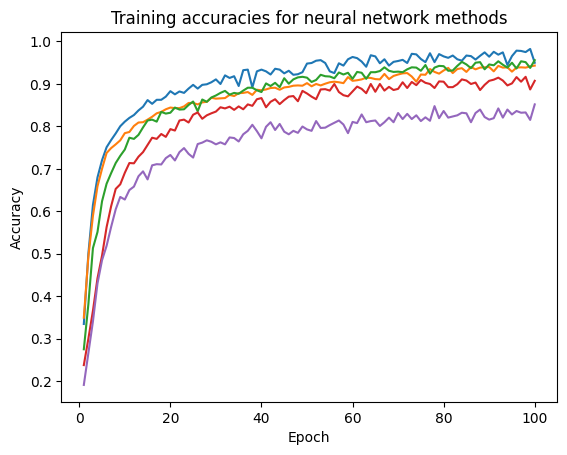

In [22]:
import matplotlib.pyplot as plt

x = np.arange(1,101)
plt.plot(x, tr_acc_1)
plt.plot(x, tr_acc_2)
plt.plot(x, tr_acc_3)
plt.plot(x, tr_acc_4)
plt.plot(x, tr_acc_5)
plt.title("Training accuracies for neural network methods")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
ax1.legend(shadow=True, fancybox=True)
plt.show()